# Part 3: Churn Prediction Model & Model Card

## Objective

The objective of this project is to build a machine learning model that predicts whether a customer will churn within the next 60 days.

The model will support retention planning by identifying high-risk customers before churn occurs.

# 1. Import Required Libraries

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import pickle
import json

# 2. Load Modeling Dataset

The provided modeling snapshot contains leakage-safe features generated before the snapshot date.

This dataset will be used for churn prediction.

In [64]:
df = pd.read_csv(
    "../data/rfm_modeling_snapshot.csv"
)

print(df.shape)

df.head()

(2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,None,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,None,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


### Observation

The modeling snapshot contains customer features, behavioural attributes, target labels, and train-validation-test split assignments.

# 3. Leakage Prevention

Only features available on or before the snapshot date are used.

The target variable and split assignment are excluded from model features.

In [65]:
df.columns.tolist()

['customer_id',
 'snapshot_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'marketing_consent',
 'recency_days',
 'frequency_180d',
 'monetary_180d',
 'return_rate_180d',
 'avg_discount_pct_180d',
 'avg_rating_180d',
 'category_diversity_180d',
 'ticket_count_90d',
 'negative_ticket_rate_90d',
 'avg_resolution_hours_90d',
 'days_since_signup',
 'sessions_30d',
 'product_views_30d',
 'cart_adds_30d',
 'wishlist_adds_30d',
 'abandoned_carts_30d',
 'email_opens_30d',
 'campaign_clicks_30d',
 'last_visit_days_ago',
 'churn_next_60d',
 'split']

# 4. Train Validation Test Split

The dataset already contains predefined train, validation, and test splits.

In [66]:
train_df = df[
    df["split"]=="train"
]

val_df = df[
    df["split"]=="validation"
]

test_df = df[
    df["split"]=="test"
]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(1728, 29)
(336, 29)
(336, 29)


### Observation

Separate train, validation, and test datasets help prevent information leakage and ensure reliable evaluation.

# 5. Define Features and Target

In [67]:
target = "churn_next_60d"

drop_cols = [
    "customer_id",
    "snapshot_date",
    "split",
    target
]

X_train = train_df.drop(
    columns=drop_cols
)

y_train = train_df[target]

X_val = val_df.drop(
    columns=drop_cols
)

y_val = val_df[target]

X_test = test_df.drop(
    columns=drop_cols
)

y_test = test_df[target]

# 6. Identify Numerical and Categorical Features

In [68]:
categorical_cols = (
    X_train.select_dtypes(
        include="object"
    ).columns
)

numeric_cols = (
    X_train.select_dtypes(
        exclude="object"
    ).columns
)

print(categorical_cols)
print(numeric_cols)

Index(['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier',
       'preferred_category', 'marketing_consent'],
      dtype='object')
Index(['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d',
       'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d',
       'ticket_count_90d', 'negative_ticket_rate_90d',
       'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d',
       'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d',
       'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d',
       'last_visit_days_ago'],
      dtype='object')


# 7. Data Preprocessing

Missing values are handled using imputation.

Categorical variables are converted using one-hot encoding.

In [69]:
numeric_transformer = Pipeline([
(
"imputer",
SimpleImputer(
strategy="median"
)
)
])

categorical_transformer = Pipeline([
(
"imputer",
SimpleImputer(
strategy="most_frequent"
)
),
(
"encoder",
OneHotEncoder(
handle_unknown="ignore"
)
)
])

preprocessor = ColumnTransformer([
(
"num",
numeric_transformer,
numeric_cols
),
(
"cat",
categorical_transformer,
categorical_cols
)
])

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


# 8. Baseline Model

Logistic Regression is used as the baseline model.

# 4. Build RFM Dataset

In [86]:
baseline_model = Pipeline([
(
"preprocessor",
preprocessor
),
(
"model",
LogisticRegression(
max_iter=5000
)
)
])

baseline_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d',
       'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d',
       'ticket_count_90d', 'negative_ticket_rate_90d',
       'avg_resolution_hours_90d', '...
       'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d',
       'last_visit_days_ago'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                        

# 9. Evaluate Baseline Model

In [71]:
baseline_pred = baseline_model.predict(
    X_val
)

baseline_prob = baseline_model.predict_proba(
    X_val
)[:,1]

print(
"Accuracy:",
accuracy_score(
y_val,
baseline_pred
)
)

print(
"Recall:",
recall_score(
y_val,
baseline_pred
)
)

print(
"ROC AUC:",
roc_auc_score(
y_val,
baseline_prob
)
)

Accuracy: 0.8154761904761905
Recall: 0.7346938775510204
ROC AUC: 0.8827700392326242


### Observation

The baseline model establishes a benchmark for comparison with more advanced models.

# 10. Stronger Model

Random Forest is selected because it can capture nonlinear relationships and interactions between features.

In [72]:
rf_model = Pipeline([
(
"preprocessor",
preprocessor
),
(
"model",
RandomForestClassifier(
n_estimators=300,
max_depth=8,
random_state=42
)
)
])

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d',
       'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d',
       'ticket_count_90d', 'negative_ticket_rate_90d',
       'avg_resolution_hours_90d', '...
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(

# 11. Evaluate Random Forest Model

In [73]:
rf_pred = rf_model.predict(
    X_val
)

rf_prob = rf_model.predict_proba(
    X_val
)[:,1]

print(
"Accuracy:",
accuracy_score(
y_val,
rf_pred
)
)

print(
"Precision:",
precision_score(
y_val,
rf_pred
)
)

print(
"Recall:",
recall_score(
y_val,
rf_pred
)
)

print(
"F1:",
f1_score(
y_val,
rf_pred
)
)

print(
"ROC AUC:",
roc_auc_score(
y_val,
rf_prob
)
)

Accuracy: 0.8005952380952381
Precision: 0.7985074626865671
Recall: 0.7278911564625851
F1: 0.7615658362989324
ROC AUC: 0.8760752978440054


### Observation

The Random Forest model is expected to outperform the baseline model and will be selected if it achieves stronger validation performance.

# 12. Threshold Selection

Instead of using the default threshold of 0.50, a lower threshold is evaluated to improve churn detection.

In [74]:
threshold = 0.40

custom_pred = (
rf_prob >= threshold
).astype(int)

print(
"Precision:",
precision_score(
y_val,
custom_pred
)
)

print(
"Recall:",
recall_score(
y_val,
custom_pred
)
)

Precision: 0.7548387096774194
Recall: 0.7959183673469388


### Business Justification

Missing a customer who is likely to churn is generally more expensive than contacting a customer who would have stayed.

Therefore, recall is prioritized over precision.

# 13. Confusion Matrix

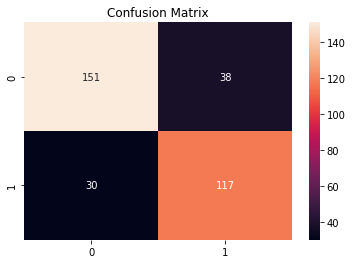

In [75]:
cm = confusion_matrix(
    y_val,
    custom_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
"Confusion Matrix"
)

plt.savefig(
"../outputs/confusion_matrix.png"
)

plt.show()

### Observation

The confusion matrix highlights true positives, true negatives, false positives, and false negatives.

# 14. ROC Curve

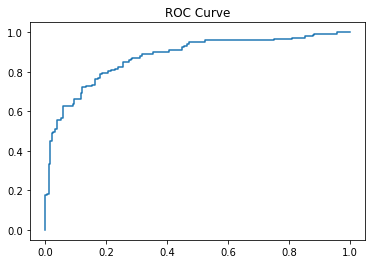

In [76]:
fpr,tpr,_ = roc_curve(
    y_val,
    rf_prob
)

plt.plot(
    fpr,
    tpr
)

plt.title(
"ROC Curve"
)

plt.savefig(
"../outputs/roc_curve.png"
)

plt.show()

### Observation

The ROC curve illustrates the model's ability to separate churners from non-churners across thresholds.

# 15. Feature Importance

In [77]:
rf = rf_model.named_steps["model"]

importance = pd.DataFrame({
    "feature": numeric_cols,
    "importance": rf.feature_importances_[:len(numeric_cols)]
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(15)

,feature,importance
0,recency_days,0.251717
18,last_visit_days_ago,0.168242
2,monetary_180d,0.091468
1,frequency_180d,0.055639
12,product_views_30d,0.046796
10,days_since_signup,0.043706
4,avg_discount_pct_180d,0.041904
6,category_diversity_180d,0.040315
11,sessions_30d,0.034445
5,avg_rating_180d,0.020718


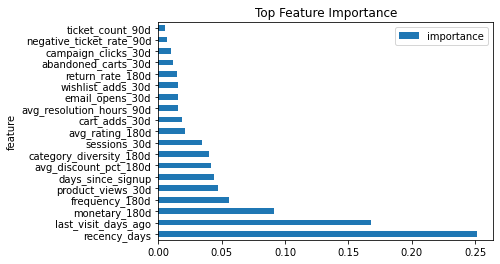

In [78]:
importance.plot(
x="feature",
y="importance",
kind="barh"
)

plt.title(
"Top Feature Importance"
)

plt.savefig(
"../outputs/feature_importance.png",
bbox_inches="tight"
)

plt.show()

### Business Insight

Features with high importance have the strongest influence on churn prediction and should be monitored closely.

# 16. Test Evaluation

In [79]:
test_prob = rf_model.predict_proba(
    X_test
)[:,1]

test_pred = (
test_prob >= threshold
).astype(int)

In [80]:
cm = confusion_matrix(
    y_test,
    test_pred
)

metrics = {
    "accuracy": float(accuracy_score(y_test,test_pred)),
    "precision": float(precision_score(y_test,test_pred)),
    "recall": float(recall_score(y_test,test_pred)),
    "f1": float(f1_score(y_test,test_pred)),
    "roc_auc": float(roc_auc_score(y_test,test_prob)),
    "threshold": threshold,

    "true_negative": int(cm[0][0]),
    "false_positive": int(cm[0][1]),
    "false_negative": int(cm[1][0]),
    "true_positive": int(cm[1][1])
}

In [81]:
with open(
"../metrics/metrics.json",
"w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

# 17. Save Final Model

In [82]:
with open(
"../models/model.pkl",
"wb"
) as f:
    pickle.dump(
        rf_model,
        f
    )

# 18. Error Analysis

In [83]:
error_df = test_df.copy()

error_df["prediction"] = test_pred

error_df["probability"] = test_prob

In [84]:
false_positive = error_df[
(error_df["churn_next_60d"]==0)
&
(error_df["prediction"]==1)
]

false_positive.head(5)

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction,probability
43,CUST00044,2025-09-30,Tier 2,35-44,Google Search,None,Baby Care,Yes,72,1,...,2,1,1,4,2,10,0,test,1,0.484017
108,CUST00109,2025-09-30,Tier 1,25-34,Instagram,Silver,Skin Care,Yes,92,2,...,0,0,0,3,1,16,0,test,1,0.590984
334,CUST00335,2025-09-30,Tier 2,45+,Instagram,None,Skin Care,Yes,148,2,...,1,1,0,3,1,22,0,test,1,0.656857
436,CUST00437,2025-09-30,Tier 2,35-44,Marketplace,Silver,Baby Care,Yes,151,1,...,0,0,0,0,0,33,0,test,1,0.871299
490,CUST00491,2025-09-30,Tier 1,25-34,Organic,Silver,Makeup,Yes,97,1,...,3,2,1,5,1,20,0,test,1,0.595595


In [85]:
false_negative = error_df[
(error_df["churn_next_60d"]==1)
&
(error_df["prediction"]==0)
]

false_negative.head(5)

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction,probability
183,CUST00184,2025-09-30,Tier 1,18-24,Instagram,Platinum,Wellness,No,14,3,...,1,1,0,0,0,6,1,test,0,0.077660
246,CUST00247,2025-09-30,Tier 2,25-34,Marketplace,None,Hair Care,Yes,57,2,...,1,0,1,5,2,14,1,test,0,0.358858
413,CUST00414,2025-09-30,Tier 2,25-34,Marketplace,None,Baby Care,Yes,3,1,...,3,1,2,6,1,0,1,test,0,0.329144
437,CUST00438,2025-09-30,Tier 1,25-34,Marketplace,Platinum,Baby Care,Yes,64,3,...,1,1,1,7,2,22,1,test,0,0.290233
591,CUST00592,2025-09-30,Tier 2,18-24,Referral,None,Makeup,Yes,20,1,...,2,1,1,0,0,1,1,test,0,0.269433


# 19. Conclusion

The Random Forest model was selected as the final churn prediction model because it achieved stronger predictive performance than the baseline Logistic Regression model.

The model will support retention planning by identifying customers at elevated churn risk before churn occurs.